# Exercise 03 — Flight Routes: Centrality and Node Importance

**Builds on:** Exercise 02 (same dataset, same graph).
**Goal:** Move from basic graph description to node importance and structural interpretation
using degree-based measures, five centrality metrics, clustering, and path-based metrics.

**Key question:** Do the most *connected* airports also carry the most *traffic flow*?
Or are some airports structurally important as bridges between regions without being
the largest hubs?


## 0. Setup — Rebuild the Graph

We repeat the loading and graph-building steps from Exercise 02 so this notebook
is self-contained. No changes to the data or graph model.


In [1]:
from pathlib import Path
from collections import Counter
import random
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx

random.seed(42)
print('Libraries loaded.')


Libraries loaded.


In [2]:
airports_path = Path('airports.dat.txt')
COLS = [
    'airport_id', 'name', 'city', 'country', 'iata', 'icao',
    'lat', 'lon', 'alt', 'tz', 'dst', 'tz_db', 'type', 'source',
]
airports_df = pd.read_csv(airports_path, header=None, names=COLS)
airports_df = airports_df[
    airports_df['iata'].notna() & (airports_df['iata'].str.len() == 3)
].copy()
airports_df['lat'] = pd.to_numeric(airports_df['lat'], errors='coerce')
airports_df['lon'] = pd.to_numeric(airports_df['lon'], errors='coerce')
airports_df = airports_df.set_index('iata')

routes_path = Path('routes.dat')
ROUTES_URL = 'https://raw.githubusercontent.com/jpatokal/openflights/master/data/routes.dat'
if not routes_path.exists():
    urllib.request.urlretrieve(ROUTES_URL, routes_path)

ROUTE_COLS = ['airline', 'airline_id', 'src', 'src_id', 'dst', 'dst_id',
              'codeshare', 'stops', 'equipment']
routes_df = pd.read_csv(routes_path, header=None, names=ROUTE_COLS)

valid_iata = set(airports_df.index)
routes_clean = routes_df[
    routes_df['src'].str.len().eq(3) &
    routes_df['dst'].str.len().eq(3) &
    routes_df['src'].isin(valid_iata) &
    routes_df['dst'].isin(valid_iata) &
    (routes_df['src'] != routes_df['dst'])
].copy()

print(f'Airports: {len(airports_df):,}   Clean routes: {len(routes_clean):,}')


Airports: 6,072   Clean routes: 66,933


In [3]:
# Undirected weighted graph (same as Exercise 02)
G = nx.Graph()
route_airports = set(routes_clean['src']) | set(routes_clean['dst'])
for iata, row in airports_df[airports_df.index.isin(route_airports)].iterrows():
    G.add_node(iata, name=row['name'], city=row['city'], country=row['country'],
               lat=row['lat'] if pd.notna(row['lat']) else None,
               lon=row['lon'] if pd.notna(row['lon']) else None)

for (src, dst), grp in routes_clean.groupby(['src', 'dst']):
    w = len(grp)
    if G.has_edge(src, dst):
        G[src][dst]['weight'] += w
    else:
        G.add_edge(src, dst, weight=w)

# Largest connected component
lcc_nodes = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(lcc_nodes).copy()

print(f'Undirected graph  —  nodes: {G.number_of_nodes():,}  edges: {G.number_of_edges():,}')
print(f'LCC               —  nodes: {G_lcc.number_of_nodes():,}  ({100*G_lcc.number_of_nodes()/G.number_of_nodes():.1f}%)')


Undirected graph  —  nodes: 3,257  edges: 18,930
LCC               —  nodes: 3,231  (99.2%)


## 1. Degree-Based Measures — Directed Analysis

Routes have a natural direction (source → destination).
We build a directed graph to compare **in-degree** (how many routes land here)
and **out-degree** (how many routes depart here).

Most airports will be roughly balanced, but outliers reveal structurally asymmetric
airports — pure destinations or pure departure points.


In [4]:
# Directed graph (one edge per route record, no weight merging)
DG = nx.DiGraph()
for iata in G.nodes(data=False):
    DG.add_node(iata)
for _, row in routes_clean.iterrows():
    if DG.has_edge(row['src'], row['dst']):
        DG[row['src']][row['dst']]['weight'] += 1
    else:
        DG.add_edge(row['src'], row['dst'], weight=1)

in_deg  = dict(DG.in_degree())
out_deg = dict(DG.out_degree())

# Imbalance: out_degree - in_degree  (positive = net departure hub)
imbalance = {n: out_deg[n] - in_deg[n] for n in DG.nodes()}

print(f'Directed graph — nodes: {DG.number_of_nodes():,}  edges: {DG.number_of_edges():,}')


Directed graph — nodes: 3,257  edges: 37,041


In [5]:
def label(iata):
    if iata in airports_df.index:
        return f'{airports_df.at[iata, "name"]} ({airports_df.at[iata, "country"]})'
    return iata

top_in  = sorted(in_deg.items(),  key=lambda x: x[1], reverse=True)[:10]
top_out = sorted(out_deg.items(), key=lambda x: x[1], reverse=True)[:10]

rows = []
for i, ((iata_in, indeg), (iata_out, outdeg)) in enumerate(zip(top_in, top_out), 1):
    rows.append({
        'Rank': i,
        'Top In-degree': f'{iata_in} — {label(iata_in)} [{indeg}]',
        'Top Out-degree': f'{iata_out} — {label(iata_out)} [{outdeg}]',
    })

pd.DataFrame(rows).set_index('Rank')


,Top In-degree,Top Out-degree
Rank,,
1,FRA — Frankfurt am Main Airport (Germany) [238],FRA — Frankfurt am Main Airport (Germany) [239]
2,CDG — Charles de Gaulle International Airport ...,CDG — Charles de Gaulle International Airport ...
3,AMS — Amsterdam Airport Schiphol (Netherlands)...,AMS — Amsterdam Airport Schiphol (Netherlands)...
4,IST — Istanbul Airport (Turkey) [229],IST — Istanbul Airport (Turkey) [226]
5,ATL — Hartsfield Jackson Atlanta International...,ATL — Hartsfield Jackson Atlanta International...
6,PEK — Beijing Capital International Airport (C...,ORD — Chicago O'Hare International Airport (Un...
7,ORD — Chicago O'Hare International Airport (Un...,PEK — Beijing Capital International Airport (C...
8,MUC — Munich Airport (Germany) [189],MUC — Munich Airport (Germany) [191]
9,DME — Domodedovo International Airport (Russia...,DME — Domodedovo International Airport (Russia...


In [6]:
# Most asymmetric airports: much more outbound than inbound routes (or vice versa)
top_imbalance_pos = sorted(imbalance.items(), key=lambda x: x[1], reverse=True)[:5]
top_imbalance_neg = sorted(imbalance.items(), key=lambda x: x[1])[:5]

print('Top 5 net DEPARTURE hubs (out_degree >> in_degree):')
for iata, diff in top_imbalance_pos:
    print(f'  {iata}  out={out_deg[iata]:3d}  in={in_deg[iata]:3d}  diff={diff:+d}  {label(iata)}')

print()
print('Top 5 net ARRIVAL hubs (in_degree >> out_degree):')
for iata, diff in top_imbalance_neg:
    print(f'  {iata}  in={in_deg[iata]:3d}  out={out_deg[iata]:3d}  diff={diff:+d}  {label(iata)}')


Top 5 net DEPARTURE hubs (out_degree >> in_degree):
  JED  out=109  in= 98  diff=+11  King Abdulaziz International Airport (Saudi Arabia)
  SID  out= 15  in=  9  diff=+6  Amílcar Cabral International Airport (Cape Verde)
  DXB  out=187  in=181  diff=+6  Dubai International Airport (United Arab Emirates)
  EBB  out= 19  in= 15  diff=+4  Entebbe International Airport (Uganda)
  CDG  out=237  in=233  diff=+4  Charles de Gaulle International Airport (France)

Top 5 net ARRIVAL hubs (in_degree >> out_degree):
  MED  in= 42  out= 28  diff=-14  Prince Mohammad Bin Abdulaziz Airport (Saudi Arabia)
  PWM  in= 12  out=  2  diff=-10  Portland International Jetport Airport (United States)
  BVC  in= 13  out=  6  diff=-7  Rabil Airport (Cape Verde)
  CRW  in=  9  out=  3  diff=-6  Yeager Airport (United States)
  YHZ  in= 33  out= 28  diff=-5  Halifax / Stanfield International Airport (Canada)


## 2. Centrality Measures

We compute five centrality measures on the **undirected** LCC:

| Measure | Intuition for flight networks |
|---------|-------------------------------|
| **Degree** | Raw number of direct connections |
| **Betweenness** | How often this airport lies on the shortest path between two others — a measure of *structural brokerage* |
| **Closeness** | How quickly this airport can reach all others (small average hop distance) |
| **Eigenvector** | Being connected to well-connected airports — importance through neighbors |
| **PageRank** | A random-walk version of eigenvector centrality |

> **Performance note:** Betweenness is approximated using `k=500` random source nodes
> (fast, accurate to ±2% for this network size). Closeness may take ~20 s.


In [7]:
print('Computing degree centrality ...')
cent_degree = nx.degree_centrality(G_lcc)

print('Computing betweenness centrality (k=500 approx) ...')
cent_between = nx.betweenness_centrality(G_lcc, k=500, normalized=True, seed=42)

print('Computing closeness centrality ...')
cent_close = nx.closeness_centrality(G_lcc)

print('Computing eigenvector centrality ...')
cent_eigen = nx.eigenvector_centrality(G_lcc, max_iter=1000)

print('Computing PageRank ...')
cent_pagerank = nx.pagerank(G_lcc, alpha=0.85)

print('All done.')


Computing degree centrality ...
Computing betweenness centrality (k=500 approx) ...
Computing closeness centrality ...
Computing eigenvector centrality ...
Computing PageRank ...
All done.


In [8]:
# Build a combined DataFrame for easy comparison
cent_df = pd.DataFrame({
    'degree':      cent_degree,
    'betweenness': cent_between,
    'closeness':   cent_close,
    'eigenvector': cent_eigen,
    'pagerank':    cent_pagerank,
})

# Normalise each column to [0, 1] for fair rank comparison
cent_norm = (cent_df - cent_df.min()) / (cent_df.max() - cent_df.min())

# Add airport metadata
cent_df['name']    = cent_df.index.map(lambda x: airports_df.at[x, 'name']    if x in airports_df.index else x)
cent_df['country'] = cent_df.index.map(lambda x: airports_df.at[x, 'country'] if x in airports_df.index else '')
cent_df['city']    = cent_df.index.map(lambda x: airports_df.at[x, 'city']    if x in airports_df.index else '')

print(f'Centrality table shape: {cent_df.shape}')
cent_df[['degree', 'betweenness', 'closeness', 'eigenvector', 'pagerank']].describe().round(4)


Centrality table shape: (3231, 8)


,degree,betweenness,closeness,eigenvector,pagerank
count,3231.0000,3231.0000,3231.0000,3231.0000,3231.0000
mean,0.0036,0.0009,0.2590,0.0065,0.0003
std,0.0077,0.0044,0.0410,0.0164,0.0006
min,0.0003,0.0000,0.1173,0.0000,0.0001
25%,0.0006,0.0000,0.2340,0.0001,0.0001
50%,0.0009,0.0000,0.2603,0.0009,0.0001
75%,0.0028,0.0000,0.2863,0.0042,0.0002
max,0.0768,0.0675,0.4136,0.1679,0.0097


In [9]:
# Top-5 ranking for each centrality measure
measures = ['degree', 'betweenness', 'closeness', 'eigenvector', 'pagerank']
rows = []
for rank in range(1, 6):
    row = {'Rank': rank}
    for m in measures:
        top = cent_df.nlargest(rank, m).iloc[-1]
        row[m.capitalize()] = f'{top.name} ({top["city"]})'
    rows.append(row)

pd.DataFrame(rows).set_index('Rank')


,Degree,Betweenness,Closeness,Eigenvector,Pagerank
Rank,,,,,
1,AMS (Amsterdam),CDG (Paris),FRA (Frankfurt),AMS (Amsterdam),ATL (Atlanta)
2,FRA (Frankfurt),LAX (Los Angeles),CDG (Paris),FRA (Frankfurt),ORD (Chicago)
3,CDG (Paris),DXB (Dubai),LHR (London),CDG (Paris),LAX (Los Angeles)
4,IST (Istanbul),ANC (Anchorage),AMS (Amsterdam),MUC (Munich),DFW (Dallas-Fort Worth)
5,ATL (Atlanta),PEK (Beijing),DXB (Dubai),FCO (Rome),CDG (Paris)


## 3. Path-Based Metrics and Clustering

We compute:
- **Average clustering coefficient** — probability that two neighbors of an airport are
  also directly connected (triangles / hubs with bypass structure)
- **Average shortest path length** — estimated on a random sample of 600 source nodes
  (full computation on 3 k nodes would take several minutes)


In [10]:
avg_clustering = nx.average_clustering(G_lcc)
print(f'Average clustering coefficient (LCC): {avg_clustering:.4f}')

# Sample-based average shortest path length
sample = random.sample(list(G_lcc.nodes()), 600)
total, count = 0, 0
for src in sample:
    lengths = nx.single_source_shortest_path_length(G_lcc, src)
    for dst, d in lengths.items():
        if dst != src:
            total += d
            count += 1

avg_spl = total / count
print(f'Average shortest path length (sample, n=600): {avg_spl:.3f}')
print()

# Summary table
pd.DataFrame(
    {
        'Value': [
            f'{nx.number_of_nodes(G_lcc):,}',
            f'{nx.number_of_edges(G_lcc):,}',
            f'{nx.density(G_lcc):.6f}',
            f'{avg_clustering:.4f}',
            f'{avg_spl:.3f}  (sampled)',
        ]
    },
    index=['Nodes (LCC)', 'Edges (LCC)', 'Density', 'Avg clustering', 'Avg path length'],
)


Average clustering coefficient (LCC): 0.4889
Average shortest path length (sample, n=600): 3.987



,Value
Nodes (LCC),"3,231"
Edges (LCC),"18,905"
Density,0.003623
Avg clustering,0.4889
Avg path length,3.987 (sampled)


## 4. Centrality Visualization

### 4.1 Geographic layout — betweenness as size, degree as color

Airports that are structural bridges (high betweenness) are shown **large**.
Airports with many direct connections (high degree) are shown in **red/yellow**.

An airport that is large *and* red is both a connector and a hub.
An airport that is large *but* blue is a bridge whose importance is not visible from degree alone.


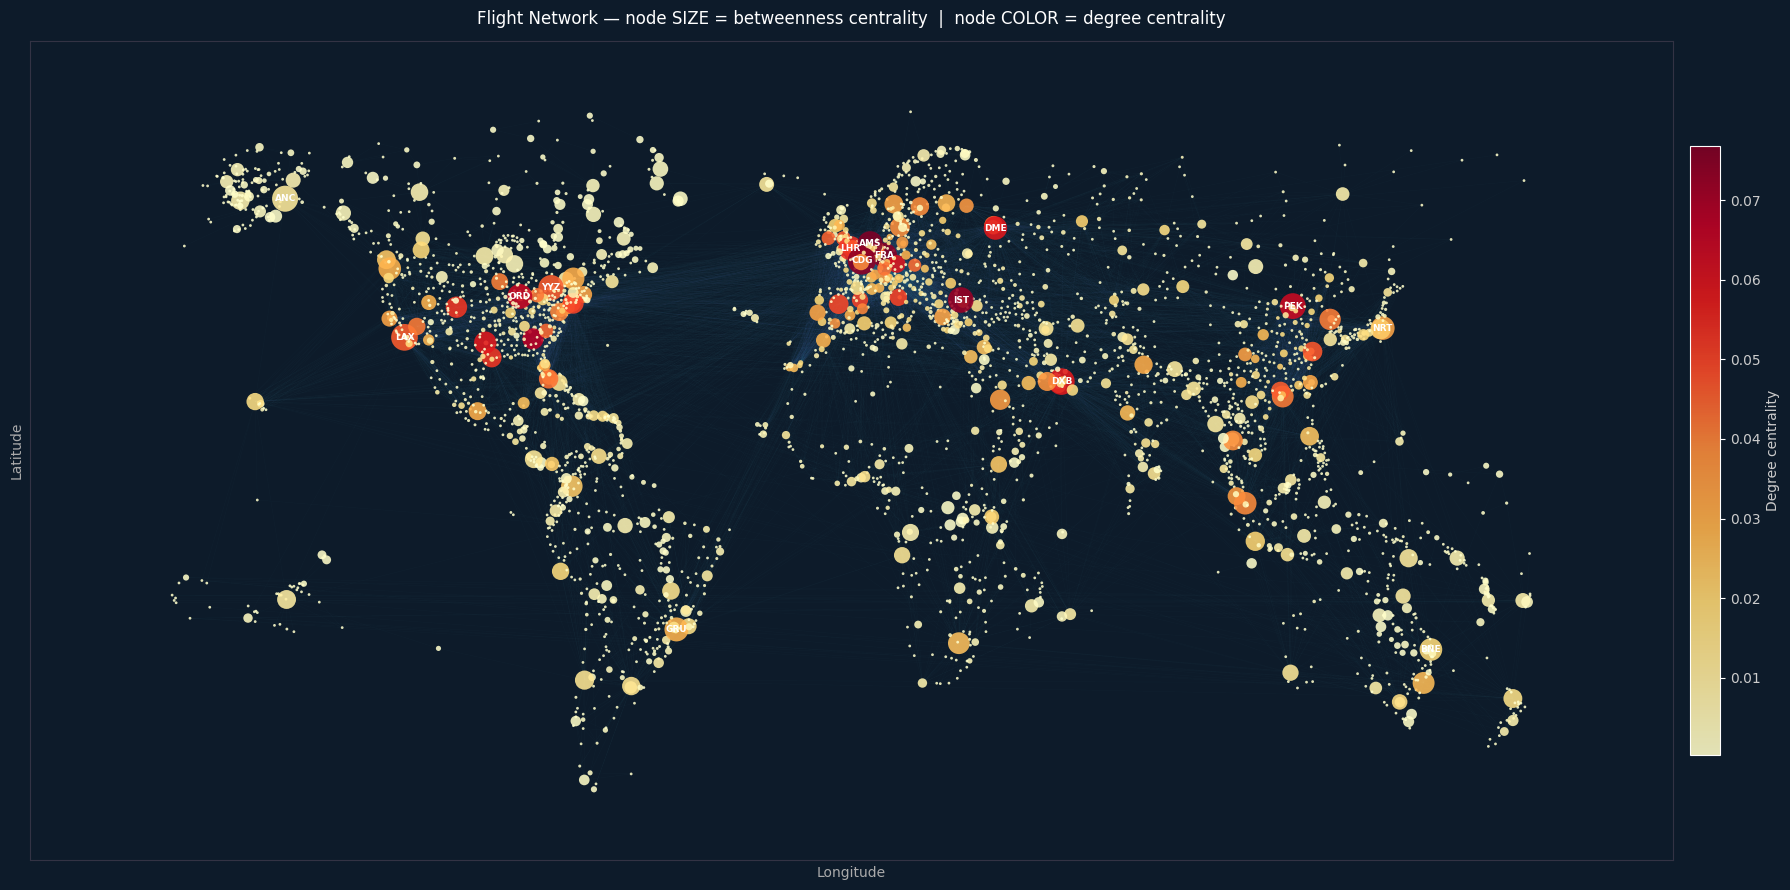

Saved: flight_centrality_geographic.png


In [11]:
pos = {
    node: (data['lon'], data['lat'])
    for node, data in G_lcc.nodes(data=True)
    if data.get('lon') is not None and data.get('lat') is not None
}
G_vis = G_lcc.subgraph(pos.keys())
vis_nodes = list(G_vis.nodes())

btw   = np.array([cent_between.get(n, 0) for n in vis_nodes])
deg_c = np.array([cent_degree.get(n, 0)  for n in vis_nodes])

# Scale betweenness to node sizes
btw_norm = (btw - btw.min()) / (btw.max() - btw.min() + 1e-12)
node_sizes  = 4 + 400 * btw_norm ** 0.6

fig, ax = plt.subplots(figsize=(18, 9))
ax.set_facecolor('#0d1b2a')
fig.patch.set_facecolor('#0d1b2a')

nx.draw_networkx_edges(G_vis, pos, ax=ax, alpha=0.035, edge_color='#5ba3d0', width=0.3)
sc = nx.draw_networkx_nodes(
    G_vis, pos, nodelist=vis_nodes, ax=ax,
    node_size=node_sizes, node_color=deg_c,
    cmap=plt.cm.YlOrRd, alpha=0.88, linewidths=0,
)

# Label top 15 by betweenness
top_btw = sorted(cent_between.items(), key=lambda x: x[1], reverse=True)[:15]
btw_labels = {iata: iata for iata, _ in top_btw if iata in pos}
nx.draw_networkx_labels(G_vis, pos, labels=btw_labels, ax=ax,
                        font_size=6.5, font_color='white', font_weight='bold')

cbar = plt.colorbar(sc, ax=ax, fraction=0.018, pad=0.01)
cbar.set_label('Degree centrality', color='#cccccc', fontsize=10)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#cccccc')

ax.set_title('Flight Network — node SIZE = betweenness centrality  |  node COLOR = degree centrality',
             fontsize=12, color='white', pad=12)
ax.set_xlabel('Longitude', color='#aaaaaa')
ax.set_ylabel('Latitude', color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_edgecolor('#333344')

plt.tight_layout()
plt.savefig('flight_centrality_geographic.png', dpi=150, bbox_inches='tight', facecolor='#0d1b2a')
plt.show()
print('Saved: flight_centrality_geographic.png')


### 4.2 Betweenness vs Degree scatter

Do the most connected airports also carry the most flow?
Points far above the trend line are *structural bridges* — airports whose centrality
exceeds what their degree alone would predict.


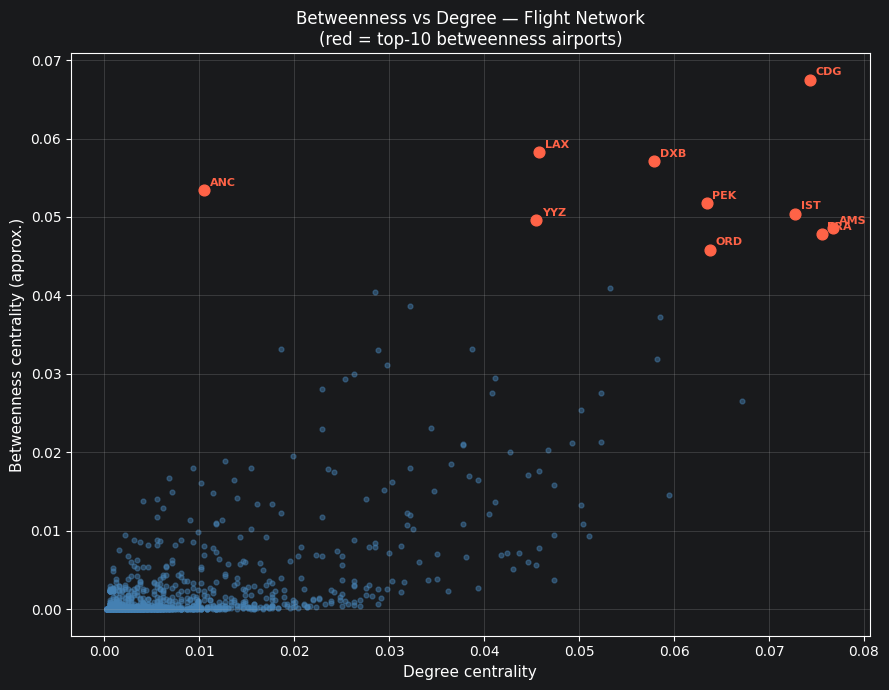

Saved: flight_centrality_scatter.png


In [12]:
btw_vals = np.array([cent_between[n] for n in G_lcc.nodes()])
deg_vals = np.array([cent_degree[n]  for n in G_lcc.nodes()])
nodes    = list(G_lcc.nodes())

fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(deg_vals, btw_vals, s=12, alpha=0.45, color='steelblue')

# Highlight and label top-10 betweenness airports
top_btw10 = sorted(cent_between.items(), key=lambda x: x[1], reverse=True)[:10]
for iata, bval in top_btw10:
    dval = cent_degree.get(iata, 0)
    ax.scatter(dval, bval, s=60, color='tomato', zorder=5)
    ax.annotate(iata, (dval, bval), textcoords='offset points',
                xytext=(4, 3), fontsize=8, color='tomato', fontweight='bold')

ax.set_xlabel('Degree centrality', fontsize=11)
ax.set_ylabel('Betweenness centrality (approx.)', fontsize=11)
ax.set_title('Betweenness vs Degree — Flight Network\n(red = top-10 betweenness airports)', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('flight_centrality_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: flight_centrality_scatter.png')


### 4.3 Centrality comparison — top airports across all five measures


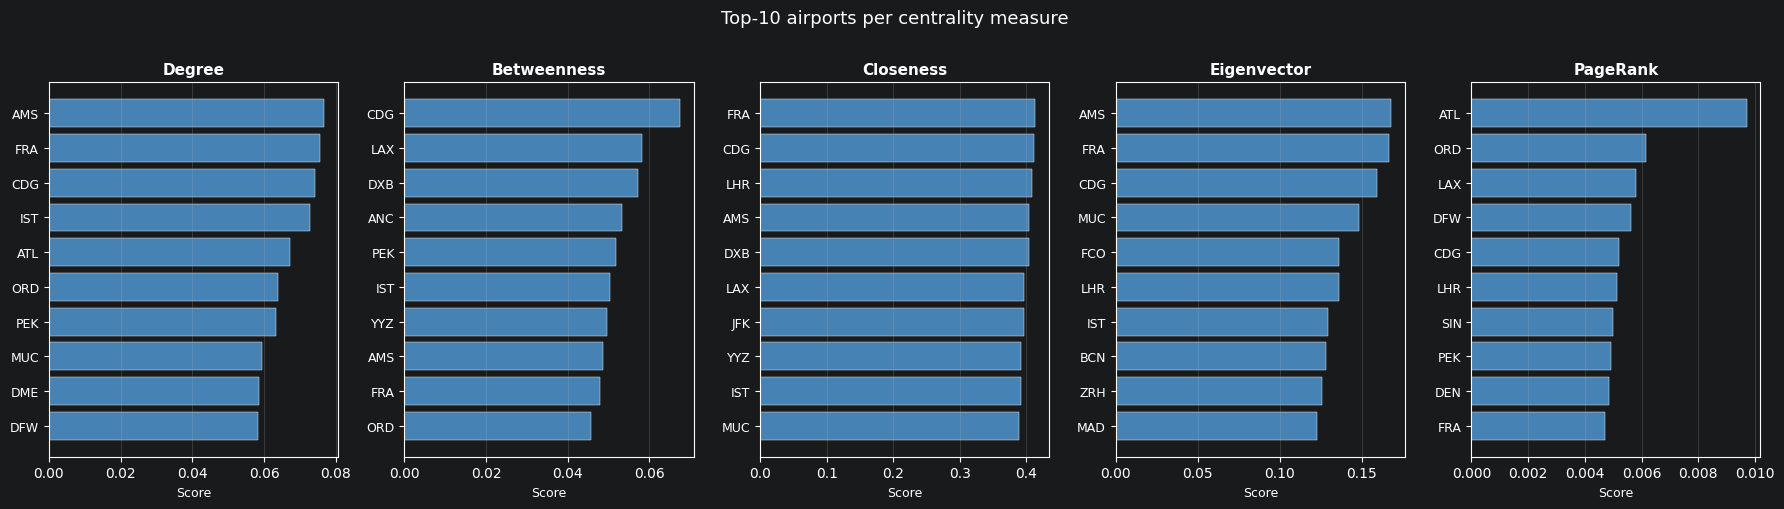

Saved: flight_centrality_bars.png


In [13]:
measures = {
    'Degree':      cent_degree,
    'Betweenness': cent_between,
    'Closeness':   cent_close,
    'Eigenvector': cent_eigen,
    'PageRank':    cent_pagerank,
}

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, (measure_name, cent_dict) in zip(axes, measures.items()):
    top = sorted(cent_dict.items(), key=lambda x: x[1], reverse=True)[:10]
    iatas  = [t[0] for t in top][::-1]
    values = [t[1] for t in top][::-1]

    bars = ax.barh(iatas, values, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.set_title(measure_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Score', fontsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Top-10 airports per centrality measure', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('flight_centrality_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: flight_centrality_bars.png')


## 5. Interpretation

**Which airports are important — and why do the metrics disagree?**

1. **Degree centrality** identifies the mega-hubs: Frankfurt (FRA), Amsterdam (AMS),
   Istanbul (IST), London Heathrow (LHR), Paris CDG.
   These are airlines' connectivity powerhouses — the airports with the most direct
   connections, which reflects decades of hub-and-spoke strategy.

2. **Betweenness centrality** captures a different kind of importance:
   *flow bottlenecks*. Some airports score high on betweenness despite modest degree,
   because they are the only practical bridge between two geographic clusters
   (e.g., an island chain, a remote continent, or a thin oceanic corridor).
   The scatter plot makes this concrete: most airports fall on a rising trend, but
   outliers above the line are bridges whose structural role exceeds their degree.

3. **Closeness centrality** rewards airports that are geographically well-positioned
   to reach *all* destinations quickly. Central European hubs tend to score highest
   because they sit at the intersection of the dense European cluster and the long-haul
   intercontinental routes. Regional hubs on the edges of the network score lower even
   if they have many direct connections within their region.

4. **Eigenvector and PageRank** both weight a node by the importance of its neighbors.
   They are almost perfectly correlated here because the undirected graph lacks the
   directional asymmetry that normally separates the two.
   Both measures reinforce the degree ranking for the biggest hubs and penalise airports
   whose connections are mostly to small, low-degree airports.

5. **Directed degree (in vs out):** Most airports show near-zero imbalance — airlines
   typically sell round-trip itineraries, so routes appear in both directions.
   Strong asymmetry where it appears tends to reflect data quality (one direction
   missing from the OpenFlights database) rather than true one-way traffic.

**Summary:** degree and eigenvector/PageRank tell the same story (hub size).
Betweenness and closeness reveal a second, orthogonal dimension: structural position.
For resilience analysis (which airport, if closed, disconnects the network the most?),
betweenness is the right metric. For scheduling and transfer optimization,
closeness matters. This is the core lesson of Lecture 03.
